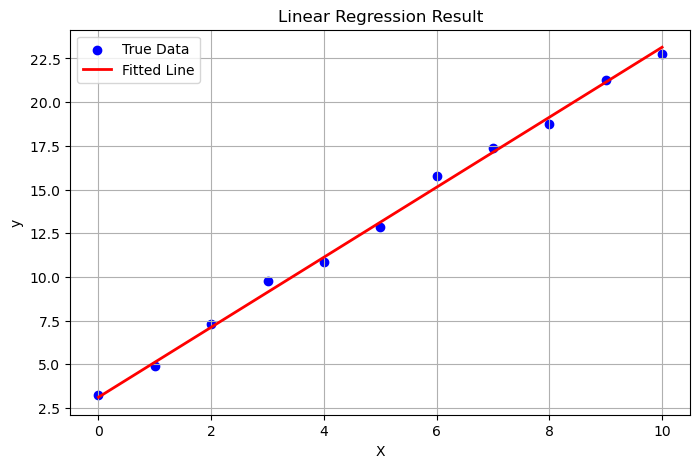

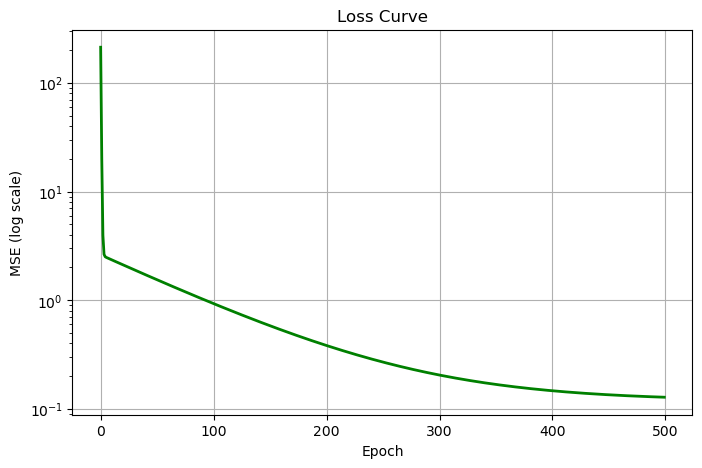

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) #设置随机种子,保持每次生成随机数相同
X=np.linspace(0,10,11).reshape(-1,1) #任意行1列 0 1 2-10 11个
#linspace 均值分配
y=2*X+3+np.random.randn(11,1)*0.5#真实值为w=2,b=3。模型是为了学习w=2,b=3
#加入均值为0,标准差为0.5的高斯噪声,模拟真实数据的误差。后面random是噪声
w=np.array([[0.0]])
b=np.array([[0.0]]) #(1,1)

lr=0.01 #学习率:控制每次更新步长
epochs=500 #迭代次数
losses=[] #记录每一轮损失值

for i in range(epochs):
    y_pred=X@w+b
    #使用均方误差MSE计算损失
    loss=np.mean((y_pred-y)**2)
    losses.append(float(loss))
    #使用均方误差MSE,因为MSE是凸函数,有唯一的全局最小值;
    #其导数形式为线性,梯度计算方便；对异常值敏感,能推动模型快速修正
    
    #反向传播:计算梯度 dl/dw，dL/db 求导
    grad_w=(2/len(X))*(X.T@(y_pred-y))
    grad_b=(2/len(X))*np.sum(y_pred-y)
    #更新参数 反向更新参数
    w=w-lr*grad_w
    b=b-lr*grad_b
    #w和b从0开始向2x+3接近
# 绘制拟合结果
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='True Data')  # 画出真实数据点（蓝色散点）
plt.plot(X, X @ w + b, color='red', linewidth=2, label='Fitted Line')  # 画出模型拟合的直线（红色）
plt.title('Linear Regression Result')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()  # 显示图例
plt.grid(True)
plt.show()

# 绘制损失曲线
plt.figure(figsize=(8, 5))          # 设置画布大小
plt.plot(range(len(losses)), losses, 'g-', linewidth=2)  # 画出损失曲线
plt.title('Loss Curve')             # 损失曲线
plt.xlabel('Epoch')                 # X轴标签；迭代次数
plt.ylabel('MSE (log scale)')       # Y轴标签；均方误差
plt.yscale('log')                   # 关键：Y轴用对数刻度，能清晰看到从高到低的完整下降过程
plt.grid(True)                      # 显示网格线，方便看数值
plt.show()
# 损失值如果从150-3相差两个数量级，用直线会变成垂直线。使用log后10^2,10^1相差只有1个单元格